# ROP Classification: Quality Subset Comparison

This notebook compares ROP classification performance across different image quality subsets:
- **Condition 1**: Good images only
- **Condition 2**: Good + Fair images

**Note**: Images classified as Bad or Worst are excluded from ROP classifier training.
Quality labels are 4-class: Good / Fair / Bad / Worst.

## Objectives
Evaluate how image quality selection affects ROP multi-task classification performance.

## Method
- Use the same v3 configuration as train_rop_classifier.ipynb
- 5-fold cross-validation with patient-level stratification
- Compare metrics: Accuracy, AUC-ROC, Quadratic Weighted Kappa

## Resume / Retrain

途中で中断した場合、**そのままセルを再実行すれば学習済みfoldはスキップされます。**

再トレーニングしたい場合は、以下の出力ディレクトリを削除してから再実行してください:

| 再実行したい範囲 | 削除するフォルダ |
|-----------------|-----------------|
| 特定のfoldだけ再実行 | `outputs_quality_comparison/{条件名}/fold_{N}/` |
| 特定の条件を全fold再実行 | `outputs_quality_comparison/{条件名}/` |
| 全て再実行 | `outputs_quality_comparison/` |

**条件名**: `good_only`, `good_fair`

例: good_onlyのfold 3だけ再実行する場合:
```
del outputs_quality_comparison\good_only\fold_3\
```

In [1]:
# ==================== Environment Setup ====================
import os
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple, Any
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
import cv2
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR

# Torchvision
import torchvision.transforms as T
from torchvision import models

# timm for EfficientNet
import timm

# Metrics
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    cohen_kappa_score, accuracy_score, f1_score
)

# Albumentations for augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# YAML for config saving
import yaml
from datetime import datetime
import json

# Set seeds for reproducibility
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Quadro RTX 5000
Memory: 17.2 GB


In [2]:
# ==================== Configuration ====================

class Config:
    """Training configuration - same as train_rop_classifier.ipynb v3"""

    # Paths
    DATA_ROOT = Path(r"E:\Multicenter_ROP_study")
    KUBOTA_DIR = DATA_ROOT / "Multicenter_images" / "Kubota_selection"
    EXCEL_PATH = DATA_ROOT / "multicenter_patient_data_20260110.xlsx"
    OUTPUT_DIR = Path(r"C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_quality_comparison")

    # Model - Same as v3
    MODEL_NAME = "efficientnet_b0"
    PRETRAINED = True
    DROPOUT = 0.5

    # Image
    IMG_SIZE = 512

    # Training - Same as v3
    BATCH_SIZE = 16
    NUM_WORKERS = 0  # Windows compatibility
    EPOCHS = 200
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-3
    PATIENCE = 10

    # Cross-validation
    N_FOLDS = 5

    # Task weights
    TASK_WEIGHTS = {
        'zone': 1.0,
        'stage': 1.0,
        'plus': 1.0,
        'aggressive_rop': 1.5,
        'treatment': 1.5
    }

    # Label smoothing
    LABEL_SMOOTHING = 0.15

    # MixUp augmentation
    MIXUP_ALPHA = 0.2
    MIXUP_P = 0.5

    # Quality comparison configurations
    # Bad/Worst are excluded from ROP classifier training
    QUALITY_CONFIGS = {
        "good_only": ["Good"],
        "good_fair": ["Good", "Fair"],
    }

    # Version info
    VERSION = "quality_comparison_v2"
    DESCRIPTION = "Quality subset comparison using v3 settings (Bad/Worst excluded)"

config = Config()

# Create output directory
config.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {config.OUTPUT_DIR}")

Output directory: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_quality_comparison


## 1. Data Loading with Quality Labels

Quality labels: Good / Fair / Bad / Worst (4-class).
Only Good and Fair are used for ROP classifier training.

In [3]:
# ==================== Load Quality-Labeled Images ====================

def load_quality_labeled_images(kubota_dir: Path) -> pd.DataFrame:
    """
    Load images from Kubota_selection folder with quality labels.
    Skips empty/corrupted files (0 bytes).
    
    Folder structure:
    Kubota_selection/
    ├── Good/
    ├── Fair/
    ├── Bad/
    └── Worst/
    """
    data = []
    skipped = 0
    
    for quality in ["Good", "Fair", "Bad", "Worst"]:
        folder = kubota_dir / quality
        if not folder.exists():
            print(f"Warning: Folder not found: {folder}")
            continue
        
        for img_path in folder.glob("*.png"):
            # Skip empty files
            if img_path.stat().st_size == 0:
                skipped += 1
                continue
            
            # Extract video_id from filename (e.g., "0001_AMU_00110.png" -> "0001_AMU")
            filename = img_path.stem
            parts = filename.rsplit('_', 1)
            if len(parts) >= 2:
                video_id = parts[0]
            else:
                video_id = filename
            
            data.append({
                "image_path": str(img_path),
                "image_name": img_path.name,
                "video_id": video_id,
                "quality": quality
            })
    
    df = pd.DataFrame(data)
    
    # Summary
    print("=== Quality Distribution ===")
    print(df['quality'].value_counts())
    print(f"\nTotal images: {len(df)}")
    if skipped > 0:
        print(f"Skipped {skipped} empty files (0 bytes)")
    
    return df

# Load quality-labeled images
quality_df = load_quality_labeled_images(config.KUBOTA_DIR)

=== Quality Distribution ===
quality
Good     4333
Bad      2588
Fair     1849
Worst     405
Name: count, dtype: int64

Total images: 9175
Skipped 43 empty files (0 bytes)


In [4]:
# ==================== Load Patient Data ====================

def load_patient_data(excel_path: Path) -> pd.DataFrame:
    """Load patient metadata from Excel file."""
    df = pd.read_excel(excel_path)
    
    print("Columns in Excel file:")
    for i, col in enumerate(df.columns):
        print(f"  {i}: {col}")
    
    return df

def preprocess_labels(df: pd.DataFrame) -> pd.DataFrame:
    """Preprocess and encode labels for multi-task classification."""
    df = df.copy()
    
    # Column mapping (adjust based on actual Excel structure)
    column_mapping = {
        'video_id': df.columns[0],
        'facility': df.columns[1],
        'zone': df.columns[6],
        'stage': df.columns[7],
        'plus': df.columns[8],
        'aggressive_rop': df.columns[9],
        'treatment': df.columns[12],
    }
    
    rename_dict = {v: k for k, v in column_mapping.items()}
    df = df.rename(columns=rename_dict)
    
    # Encode Zone (1, 2, 3) -> (0, 1, 2)
    df['zone_label'] = df['zone'].apply(
        lambda x: int(x) - 1 if pd.notna(x) and str(x).isdigit() else -1
    )
    
    # Encode Stage (0, 1, 2, 3) -> (0, 1, 2, 3)
    df['stage_label'] = df['stage'].apply(
        lambda x: int(x) if pd.notna(x) and str(x).isdigit() else -1
    )
    
    # Encode Plus (normal, preplus, plus) -> (0, 1, 2)
    plus_mapping = {'normal': 0, 'preplus': 1, 'plus': 2}
    df['plus_label'] = df['plus'].apply(
        lambda x: plus_mapping.get(str(x).lower().strip(), -1) if pd.notna(x) else -1
    )
    
    # Encode Aggressive ROP (Yes/No) -> (1/0)
    df['aggressive_rop_label'] = df['aggressive_rop'].apply(
        lambda x: 1 if str(x).lower().strip() in ['yes', 'y', '1', 'true'] else 0
    )
    
    # Encode Treatment (Yes/No) -> (1/0)
    df['treatment_label'] = df['treatment'].apply(
        lambda x: 1 if str(x).lower().strip() in ['yes', 'y', '1', 'true'] else 0
    )
    
    return df

# Load and preprocess patient data
patient_df = load_patient_data(config.EXCEL_PATH)
patient_df = preprocess_labels(patient_df)
print(f"\nLoaded {len(patient_df)} patient records")

Columns in Excel file:
  0: 動画番号
  1: 施設
  2: 性別
  3: GA(week)
  4: BW(g)
  5: PMA(week)
  6: Zone
  7: Stage
  8: Plus(Normal:0 PrePlus:1 Plus:2)
  9: Aggressive ROP(無:0 有:1)
  10: Act-ROPスコア
  11: スコアによる重症度分類(mild:0 moderate:1 sever:2)
  12: 治療すべきか否か(不要:0 必要:1)
  13: 実際に治療したかどうか(無:0 有:1)
  14: 治療前後(前:1 後:2)
  15: その他コメント

Loaded 304 patient records


In [5]:
# ==================== Merge Quality Labels with Patient Data ====================

def merge_quality_and_labels(quality_df: pd.DataFrame, patient_df: pd.DataFrame) -> pd.DataFrame:
    """Merge quality-labeled images with patient ROP labels."""
    
    # Merge on video_id
    merged = quality_df.merge(
        patient_df[['video_id', 'facility', 'zone_label', 'stage_label', 'plus_label', 
                    'aggressive_rop_label', 'treatment_label']],
        on='video_id',
        how='left'
    )
    
    # Check for missing labels
    missing = merged[merged['zone_label'].isna()]
    if len(missing) > 0:
        print(f"Warning: {len(missing)} images without matching labels")
        print(f"Missing video_ids: {missing['video_id'].unique()[:10]}...")
    
    # Remove rows with missing labels
    merged = merged.dropna(subset=['zone_label'])
    
    print(f"\nMerged dataset size: {len(merged)}")
    print(f"\n=== Quality Distribution (after merge) ===")
    print(merged['quality'].value_counts())
    
    return merged

# Merge datasets
dataset_df = merge_quality_and_labels(quality_df, patient_df)

# Display label distribution
print("\n=== Label Distribution ===")
for col in ['zone_label', 'stage_label', 'plus_label', 'aggressive_rop_label', 'treatment_label']:
    if col in dataset_df.columns:
        print(f"\n{col}:")
        print(dataset_df[col].value_counts().sort_index())

Missing video_ids: ['0307_FU' '0308_FU' '0309_FU' '0310_FU' '0311_FU' '0312_FU' '0313_FU'
 '0317_FU' '0318_FU' '0319_FU']...

Merged dataset size: 7424

=== Quality Distribution (after merge) ===
quality
Good     3453
Bad      2220
Fair     1525
Worst     226
Name: count, dtype: int64

=== Label Distribution ===

zone_label:
zone_label
0.0    1093
1.0    4665
2.0    1666
Name: count, dtype: int64

stage_label:
stage_label
-1.0      28
 0.0    3041
 1.0    1840
 2.0    1189
 3.0    1326
Name: count, dtype: int64

plus_label:
plus_label
-1.0    7424
Name: count, dtype: int64

aggressive_rop_label:
aggressive_rop_label
0.0    7151
1.0     273
Name: count, dtype: int64

treatment_label:
treatment_label
0.0    6490
1.0     934
Name: count, dtype: int64


## 2. Dataset and Augmentation

In [6]:
# ==================== Data Augmentation ====================

def get_train_transforms(img_size: int = 512) -> A.Compose:
    """Training augmentation pipeline (same as v3)."""
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Rotate(limit=180, p=0.9, border_mode=cv2.BORDER_CONSTANT, value=0),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.OneOf([
            A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=1.0),
            A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=1.0),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=20, p=1.0),
        ], p=0.7),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        A.OneOf([
            A.GaussianBlur(blur_limit=(3, 7), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
            A.MedianBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
        A.RandomResizedCrop(size=(img_size, img_size), scale=(0.85, 1.0), ratio=(0.9, 1.1), p=0.4),
        A.CoarseDropout(max_holes=8, max_height=img_size//16, max_width=img_size//16, min_holes=1, fill_value=0, p=0.3),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

def get_valid_transforms(img_size: int = 512) -> A.Compose:
    """Validation transforms (no augmentation)."""
    return A.Compose([
        A.Resize(img_size, img_size),
        A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ToTensorV2(),
    ])

train_transforms = get_train_transforms(config.IMG_SIZE)
valid_transforms = get_valid_transforms(config.IMG_SIZE)
print("Transforms defined successfully")

Transforms defined successfully


In [7]:
# ==================== Dataset Class ====================

class ROPDataset(Dataset):
    """PyTorch Dataset for ROP multi-task classification."""
    
    def __init__(self, df: pd.DataFrame, transforms: A.Compose = None):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms
        self.task_columns = {
            'zone': 'zone_label',
            'stage': 'stage_label',
            'plus': 'plus_label',
            'aggressive_rop': 'aggressive_rop_label',
            'treatment': 'treatment_label'
        }
    
    def __len__(self) -> int:
        return len(self.df)
    
    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        
        image = cv2.imread(row['image_path'])
        if image is None:
            raise ValueError(f"Failed to load image: {row['image_path']}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        if self.transforms:
            transformed = self.transforms(image=image)
            image = transformed['image']
        
        labels = {}
        for task_name, col_name in self.task_columns.items():
            label = row.get(col_name, -1)
            labels[task_name] = torch.tensor(int(label), dtype=torch.long)
        
        return {
            'image': image,
            'labels': labels,
            'image_path': row['image_path']
        }

## 3. Model Architecture

In [8]:
# ==================== Multi-Task Model ====================

class MultiTaskHead(nn.Module):
    """Classification head for a single task."""
    
    def __init__(self, in_features: int, num_classes: int, dropout: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(x)


class ROPMultiTaskModel(nn.Module):
    """Multi-task classification model for ROP."""
    
    TASK_CONFIG = {
        'zone': (3, True),
        'stage': (4, True),
        'plus': (3, True),
        'aggressive_rop': (2, False),
        'treatment': (2, False)
    }
    
    def __init__(self, model_name: str = "efficientnet_b0", pretrained: bool = True, dropout: float = 0.3):
        super().__init__()
        self.model_name = model_name
        
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        in_features = self.backbone.num_features
        print(f"Backbone: {model_name}, features: {in_features}")
        
        self.heads = nn.ModuleDict()
        for task_name, (num_classes, _) in self.TASK_CONFIG.items():
            self.heads[task_name] = MultiTaskHead(in_features, num_classes, dropout)
    
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        features = self.backbone(x)
        outputs = {}
        for task_name, head in self.heads.items():
            outputs[task_name] = head(features)
        return outputs

## 4. Loss Functions and Metrics

In [9]:
# ==================== Loss Functions ====================

class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance."""
    
    def __init__(self, alpha: float = 1.0, gamma: float = 2.0, reduction: str = 'mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, inputs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class MultiTaskLoss(nn.Module):
    """Combined loss for multi-task learning."""
    
    def __init__(self, task_weights: Dict[str, float] = None, label_smoothing: float = 0.1):
        super().__init__()
        self.task_weights = task_weights or {
            'zone': 1.0, 'stage': 1.0, 'plus': 1.0,
            'aggressive_rop': 1.5, 'treatment': 1.5
        }
        self.label_smoothing = label_smoothing
        self.focal_loss = FocalLoss(gamma=2.0)
    
    def forward(self, outputs: Dict[str, torch.Tensor], labels: Dict[str, torch.Tensor]) -> Tuple[torch.Tensor, Dict[str, torch.Tensor]]:
        total_loss = 0.0
        task_losses = {}
        
        for task_name, output in outputs.items():
            target = labels[task_name]
            mask = target >= 0
            
            if mask.sum() == 0:
                task_losses[task_name] = torch.tensor(0.0, device=output.device)
                continue
            
            output = output[mask]
            target = target[mask]
            
            ce_loss = F.cross_entropy(output, target, label_smoothing=self.label_smoothing)
            focal = self.focal_loss(output, target)
            loss = (ce_loss + focal) / 2
            
            weight = self.task_weights.get(task_name, 1.0)
            task_losses[task_name] = loss
            total_loss += weight * loss
        
        return total_loss, task_losses

In [10]:
# ==================== Metrics ====================

def compute_metrics(preds: Dict[str, np.ndarray], labels: Dict[str, np.ndarray]) -> Dict[str, Dict[str, float]]:
    """Compute metrics for all tasks."""
    metrics = {}
    
    for task_name in preds.keys():
        y_pred = preds[task_name]
        y_true = labels[task_name]
        
        # Filter out invalid labels
        mask = y_true >= 0
        y_pred = y_pred[mask]
        y_true = y_true[mask]
        
        if len(y_true) == 0:
            metrics[task_name] = {'accuracy': 0.0, 'kappa': 0.0}
            continue
        
        pred_classes = y_pred.argmax(axis=1) if y_pred.ndim > 1 else y_pred
        
        task_metrics = {
            'accuracy': accuracy_score(y_true, pred_classes),
            'kappa': cohen_kappa_score(y_true, pred_classes, weights='quadratic')
        }
        
        # AUC for binary tasks
        if task_name in ['aggressive_rop', 'treatment']:
            try:
                probs = torch.softmax(torch.tensor(y_pred), dim=1)[:, 1].numpy()
                task_metrics['auc'] = roc_auc_score(y_true, probs)
            except:
                task_metrics['auc'] = 0.0
        
        metrics[task_name] = task_metrics
    
    return metrics

## 5. Training Functions

In [11]:
# ==================== MixUp ====================

def mixup_data(x, y, alpha=0.2):
    """Apply MixUp augmentation."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x.size(0)
    index = torch.randperm(batch_size).to(x.device)
    
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, {k: v[index] for k, v in y.items()}
    
    return mixed_x, y_a, y_b, lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute MixUp loss."""
    loss_a, _ = criterion(pred, y_a)
    loss_b, _ = criterion(pred, y_b)
    return lam * loss_a + (1 - lam) * loss_b

In [12]:
# ==================== Training Loop ====================

def train_epoch(model, dataloader, criterion, optimizer, scheduler, device, mixup_alpha=0.2, mixup_p=0.5):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    
    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        labels = {k: v.to(device) for k, v in batch['labels'].items()}
        
        # MixUp
        if np.random.random() < mixup_p:
            images, labels_a, labels_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(images)
            loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        else:
            outputs = model(images)
            loss, _ = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        
        running_loss += loss.item()
    
    return running_loss / len(dataloader)


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    running_loss = 0.0
    all_preds = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
    all_labels = {task: [] for task in ROPMultiTaskModel.TASK_CONFIG.keys()}
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation", leave=False):
            images = batch['image'].to(device)
            labels = {k: v.to(device) for k, v in batch['labels'].items()}
            
            outputs = model(images)
            loss, _ = criterion(outputs, labels)
            running_loss += loss.item()
            
            for task in all_preds.keys():
                all_preds[task].append(outputs[task].cpu().numpy())
                all_labels[task].append(labels[task].cpu().numpy())
    
    # Concatenate
    for task in all_preds.keys():
        all_preds[task] = np.concatenate(all_preds[task])
        all_labels[task] = np.concatenate(all_labels[task])
    
    metrics = compute_metrics(all_preds, all_labels)
    
    return running_loss / len(dataloader), metrics, all_preds, all_labels

In [13]:
# ==================== Cross-Validation ====================

def run_cross_validation(df: pd.DataFrame, output_dir: Path, config: Config) -> Dict:
    """Run 5-fold cross-validation. Skips already trained folds (resume support)."""
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Create stratification target (combined zone and stage)
    df['stratify_target'] = df['zone_label'].astype(str) + '_' + df['stage_label'].astype(str)
    
    # StratifiedGroupKFold (patient-level split)
    sgkf = StratifiedGroupKFold(n_splits=config.N_FOLDS, shuffle=True, random_state=42)
    
    all_fold_results = []
    all_predictions = []
    
    for fold, (train_idx, val_idx) in enumerate(sgkf.split(df, df['stratify_target'], df['video_id'])):
        fold_dir = output_dir / f"fold_{fold + 1}"
        fold_dir.mkdir(exist_ok=True)
        
        best_model_path = fold_dir / "best_model.pt"
        
        # ----- Skip if already trained -----
        if best_model_path.exists():
            print(f"\n{'='*50}")
            print(f"Fold {fold + 1}/{config.N_FOLDS} - SKIPPED (already trained)")
            print(f"  Model: {best_model_path}")
            print(f"{'='*50}")
            
            # Still need to evaluate to collect results
            val_df = df.iloc[val_idx].reset_index(drop=True)
            val_dataset = ROPDataset(val_df, transforms=valid_transforms)
            val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS)
            
            model = ROPMultiTaskModel(model_name=config.MODEL_NAME, pretrained=False, dropout=config.DROPOUT)
            model.load_state_dict(torch.load(best_model_path, map_location=device))
            model = model.to(device)
            
            criterion = MultiTaskLoss(task_weights=config.TASK_WEIGHTS, label_smoothing=config.LABEL_SMOOTHING)
            val_loss, final_metrics, preds, labels = validate_epoch(model, val_loader, criterion, device)
            
            fold_result = {
                'fold': fold + 1,
                'train_size': len(train_idx),
                'val_size': len(val_idx),
                'best_val_loss': val_loss,
                'metrics': final_metrics,
                'train_losses': [],
                'val_losses': []
            }
            all_fold_results.append(fold_result)
            
            for i, row in val_df.iterrows():
                pred_entry = {
                    'fold': fold + 1,
                    'image_path': row['image_path'],
                    'video_id': row['video_id'],
                    'quality': row['quality']
                }
                idx = val_df.index.get_loc(i)
                for task in preds.keys():
                    pred_entry[f'{task}_label'] = labels[task][idx]
                    pred_entry[f'{task}_pred'] = preds[task][idx].argmax()
                all_predictions.append(pred_entry)
            
            del model
            torch.cuda.empty_cache()
            continue
        
        # ----- Train fold -----
        print(f"\n{'='*50}")
        print(f"Fold {fold + 1}/{config.N_FOLDS}")
        print(f"{'='*50}")
        
        # Split data
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)
        
        print(f"Train: {len(train_df)}, Val: {len(val_df)}")
        
        # Create datasets
        train_dataset = ROPDataset(train_df, transforms=train_transforms)
        val_dataset = ROPDataset(val_df, transforms=valid_transforms)
        
        train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=config.NUM_WORKERS)
        val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=config.NUM_WORKERS)
        
        # Initialize model
        model = ROPMultiTaskModel(model_name=config.MODEL_NAME, pretrained=config.PRETRAINED, dropout=config.DROPOUT)
        model = model.to(device)
        
        # Loss, optimizer, scheduler
        criterion = MultiTaskLoss(task_weights=config.TASK_WEIGHTS, label_smoothing=config.LABEL_SMOOTHING)
        optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
        scheduler = OneCycleLR(optimizer, max_lr=config.LEARNING_RATE, epochs=config.EPOCHS, steps_per_epoch=len(train_loader))
        
        # Training loop
        best_val_loss = float('inf')
        patience_counter = 0
        train_losses = []
        val_losses = []
        
        for epoch in range(config.EPOCHS):
            train_loss = train_epoch(model, train_loader, criterion, optimizer, scheduler, device, config.MIXUP_ALPHA, config.MIXUP_P)
            val_loss, metrics, _, _ = validate_epoch(model, val_loader, criterion, device)
            
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            print(f"Epoch {epoch + 1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            
            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save(model.state_dict(), best_model_path)
            else:
                patience_counter += 1
                if patience_counter >= config.PATIENCE:
                    print(f"Early stopping at epoch {epoch + 1}")
                    break
        
        # Load best model and evaluate
        model.load_state_dict(torch.load(best_model_path))
        _, final_metrics, preds, labels = validate_epoch(model, val_loader, criterion, device)
        
        # Save fold results
        fold_result = {
            'fold': fold + 1,
            'train_size': len(train_df),
            'val_size': len(val_df),
            'best_val_loss': best_val_loss,
            'metrics': final_metrics,
            'train_losses': train_losses,
            'val_losses': val_losses
        }
        all_fold_results.append(fold_result)
        
        # Save predictions
        for i, row in val_df.iterrows():
            pred_entry = {
                'fold': fold + 1,
                'image_path': row['image_path'],
                'video_id': row['video_id'],
                'quality': row['quality']
            }
            idx = val_df.index.get_loc(i)
            for task in preds.keys():
                pred_entry[f'{task}_label'] = labels[task][idx]
                pred_entry[f'{task}_pred'] = preds[task][idx].argmax()
            all_predictions.append(pred_entry)
        
        # Cleanup
        del model, optimizer, scheduler
        torch.cuda.empty_cache()
    
    # Save all results
    results_df = pd.DataFrame(all_predictions)
    results_df.to_csv(output_dir / "predictions.csv", index=False)
    
    return {
        'fold_results': all_fold_results,
        'predictions_df': results_df
    }

## 6. Run Quality Comparison Experiments

In [14]:
# ==================== Run All Experiments ====================

all_results = {}

for config_name, quality_groups in config.QUALITY_CONFIGS.items():
    print(f"\n{'#'*60}")
    print(f"# Experiment: {config_name}")
    print(f"# Quality groups: {quality_groups}")
    print(f"{'#'*60}")
    
    output_dir = config.OUTPUT_DIR / config_name
    
    # Check how many folds are already trained
    trained_folds = sum(1 for i in range(1, config.N_FOLDS + 1) 
                        if (output_dir / f"fold_{i}" / "best_model.pt").exists())
    
    if trained_folds == config.N_FOLDS:
        print(f"  All {config.N_FOLDS} folds already trained. Evaluating saved models...")
    elif trained_folds > 0:
        print(f"  {trained_folds}/{config.N_FOLDS} folds already trained. Resuming...")
    
    # Filter dataset
    df_subset = dataset_df[dataset_df['quality'].isin(quality_groups)].copy()
    print(f"Dataset size: {len(df_subset)}")
    print(f"Quality distribution: {df_subset['quality'].value_counts().to_dict()}")
    
    # Run cross-validation (skips already trained folds)
    results = run_cross_validation(df_subset, output_dir, config)
    all_results[config_name] = results
    
    print(f"\nCompleted: {config_name}")


############################################################
# Experiment: good_only
# Quality groups: ['Good']
############################################################
  All 5 folds already trained. Evaluating saved models...
Dataset size: 3453
Quality distribution: {'Good': 3453}

Fold 1/5 - SKIPPED (already trained)
  Model: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_quality_comparison\good_only\fold_1\best_model.pt
Backbone: efficientnet_b0, features: 1280


Validation:   0%|          | 0/41 [00:00<?, ?it/s]


Fold 2/5 - SKIPPED (already trained)
  Model: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_quality_comparison\good_only\fold_2\best_model.pt
Backbone: efficientnet_b0, features: 1280


Validation:   0%|          | 0/43 [00:00<?, ?it/s]


Fold 3/5 - SKIPPED (already trained)
  Model: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_quality_comparison\good_only\fold_3\best_model.pt
Backbone: efficientnet_b0, features: 1280


...

Training:   0%|          | 0/253 [00:00<?, ?it/s]

Validation:   0%|          | 0/59 [00:00<?, ?it/s]

Epoch 25: Train Loss: 1.3313, Val Loss: 2.0268
Early stopping at epoch 25


Validation:   0%|          | 0/59 [00:00<?, ?it/s]


Completed: good_fair


## 7. Results Comparison

In [15]:
# ==================== Aggregate Results ====================

def aggregate_fold_metrics(fold_results: List[Dict]) -> Dict[str, Dict[str, Tuple[float, float]]]:
    """Aggregate metrics across folds (mean ± std)."""
    aggregated = {}
    
    tasks = fold_results[0]['metrics'].keys()
    for task in tasks:
        task_metrics = {}
        for metric_name in fold_results[0]['metrics'][task].keys():
            values = [f['metrics'][task][metric_name] for f in fold_results]
            task_metrics[metric_name] = (np.mean(values), np.std(values))
        aggregated[task] = task_metrics
    
    return aggregated

# Create comparison table
comparison_data = []

for config_name, results in all_results.items():
    agg_metrics = aggregate_fold_metrics(results['fold_results'])
    
    for task, metrics in agg_metrics.items():
        for metric_name, (mean, std) in metrics.items():
            comparison_data.append({
                'Config': config_name,
                'Task': task,
                'Metric': metric_name,
                'Mean': mean,
                'Std': std,
                'Value': f"{mean:.4f} ± {std:.4f}"
            })

comparison_df = pd.DataFrame(comparison_data)

# Pivot table for easy viewing
pivot_df = comparison_df.pivot_table(
    index=['Task', 'Metric'],
    columns='Config',
    values='Value',
    aggfunc='first'
)

print("\n=== Performance Comparison ===")
display(pivot_df)


=== Performance Comparison ===


Config                         good_fair        good_only
Task           Metric                                    
aggressive_rop accuracy  0.9683 ± 0.0243  0.9623 ± 0.0172
               auc       0.9643 ± 0.0295  0.7724 ± 0.3871
               kappa     0.5175 ± 0.3393  0.2688 ± 0.2326
plus           accuracy  0.0000 ± 0.0000  0.0000 ± 0.0000
               kappa     0.0000 ± 0.0000  0.0000 ± 0.0000
stage          accuracy  0.6516 ± 0.0759  0.6470 ± 0.0352
               kappa     0.6576 ± 0.0718  0.6486 ± 0.1252
treatment      accuracy  0.9413 ± 0.0423  0.9392 ± 0.0214
               auc       0.9620 ± 0.0268  0.9717 ± 0.0123
               kappa     0.7311 ± 0.1580  0.6892 ± 0.1152
zone           accuracy  0.7125 ± 0.0609  0.7194 ± 0.0778
               kappa     0.4820 ± 0.1325  0.4596 ± 0.1675

### 7.1 Detailed Per-Task Metrics (Sensitivity / Specificity / PPV / NPV / F1 / AUC)

In [ ]:
# ==================== Detailed Per-Task Metrics ====================
from sklearn.preprocessing import label_binarize

task_class_names = {
    'zone': {0: 'Zone I', 1: 'Zone II', 2: 'Zone III'},
    'stage': {0: 'Stage 0', 1: 'Stage 1', 2: 'Stage 2', 3: 'Stage 3'},
    'aggressive_rop': {0: 'No', 1: 'Yes'},
    'treatment': {0: 'No', 1: 'Yes'},
}

detailed_results = {}

for config_name, results in all_results.items():
    pred_df = results['predictions_df']
    print(f"\n{'#' * 70}")
    print(f"# {config_name.upper()} (n={len(pred_df)})")
    print(f"{'#' * 70}")

    cond_detail = {}

    for task, class_map in task_class_names.items():
        label_col = f'{task}_label'
        pred_col = f'{task}_pred'

        y_true = pred_df[label_col].values.astype(int)
        y_pred = pred_df[pred_col].values.astype(int)

        mask = y_true >= 0
        y_true = y_true[mask]
        y_pred = y_pred[mask]

        if len(y_true) == 0:
            print(f"\n  [{task}] No valid labels. Skipping.")
            continue

        classes = sorted(class_map.keys())
        cnames = [class_map[c] for c in classes]

        acc = accuracy_score(y_true, y_pred)
        kappa = cohen_kappa_score(y_true, y_pred, weights='quadratic')
        f1_mac = f1_score(y_true, y_pred, average='macro', zero_division=0)

        cm = confusion_matrix(y_true, y_pred, labels=classes)

        print(f"\n{'=' * 60}")
        print(f"  {task.upper()} | Accuracy: {acc:.4f} | Kappa: {kappa:.4f} | Macro F1: {f1_mac:.4f}")
        print(f"{'=' * 60}")

        rows = []
        for i, cls in enumerate(classes):
            tp = cm[i, i]
            fn = cm[i, :].sum() - tp
            fp = cm[:, i].sum() - tp
            tn = cm.sum() - tp - fn - fp
            n = int(cm[i, :].sum())

            sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
            f1v = 2 * ppv * sens / (ppv + sens) if (ppv + sens) > 0 else 0.0

            rows.append({'Class': cnames[i], 'n': n,
                         'Sensitivity': round(sens, 4), 'Specificity': round(spec, 4),
                         'PPV': round(ppv, 4), 'NPV': round(npv, 4), 'F1': round(f1v, 4)})

        detail_df = pd.DataFrame(rows)
        display(detail_df)

        # AUC for binary tasks
        if task in ['aggressive_rop', 'treatment']:
            try:
                auc = roc_auc_score(y_true, y_pred)
                print(f"  AUC-ROC (label-based): {auc:.4f}")
            except:
                pass

        cond_detail[task] = {'acc': acc, 'kappa': kappa, 'f1_macro': f1_mac, 'per_class': rows}

    detailed_results[config_name] = cond_detail

### 7.2 Condition Comparison (good_only vs good_fair)

In [ ]:
# ==================== Condition Comparison Table ====================

comparison_rows = []
for task in ['zone', 'stage', 'aggressive_rop', 'treatment']:
    if task not in detailed_results.get('good_only', {}):
        continue
    r1 = detailed_results['good_only'][task]
    r2 = detailed_results['good_fair'][task]

    for metric in ['acc', 'kappa', 'f1_macro']:
        v1 = r1[metric]
        v2 = r2[metric]
        diff = v2 - v1
        comparison_rows.append({
            'Task': task.upper(),
            'Metric': metric,
            'good_only': round(v1, 4),
            'good_fair': round(v2, 4),
            'Difference': f'{diff:+.4f}',
        })

comp_df = pd.DataFrame(comparison_rows)
print('=' * 70)
print('CONDITION COMPARISON: good_only vs good_fair')
print('=' * 70)
display(comp_df)

# Save detailed results to Excel
with pd.ExcelWriter(config.OUTPUT_DIR / 'detailed_evaluation.xlsx') as writer:
    comp_df.to_excel(writer, sheet_name='Comparison', index=False)
    for config_name in detailed_results:
        for task, data in detailed_results[config_name].items():
            sheet = f'{config_name}_{task}'[:31]
            pd.DataFrame(data['per_class']).to_excel(writer, sheet_name=sheet, index=False)

print(f'\nSaved to: {config.OUTPUT_DIR / "detailed_evaluation.xlsx"}')


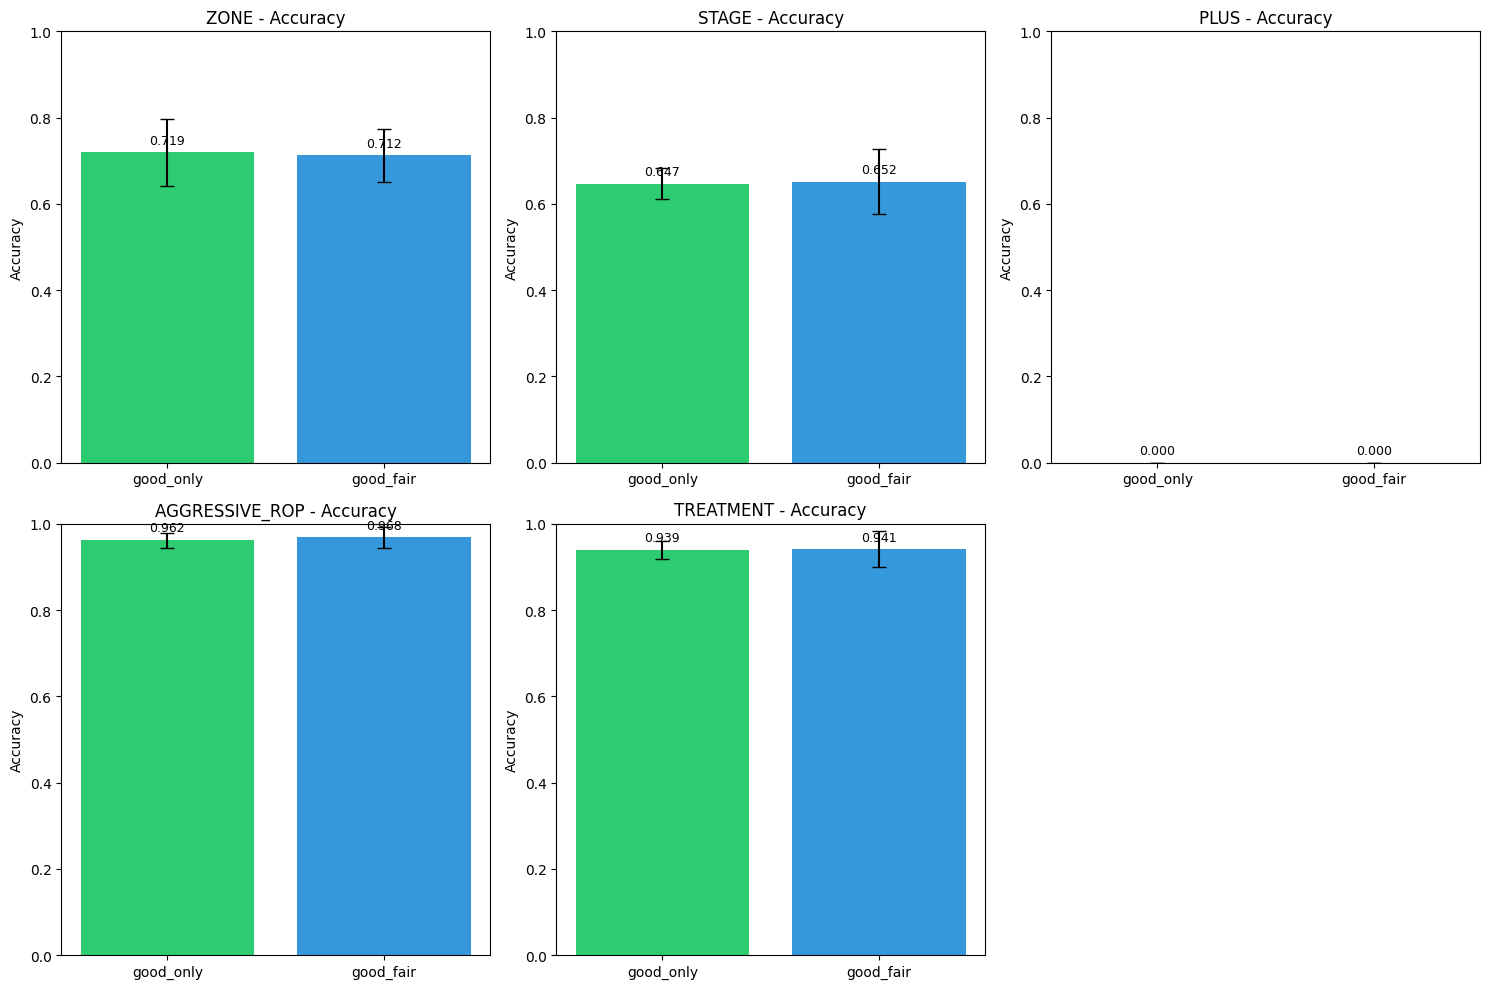

Figure saved to: C:\Users\ykita\ROP_AI_project\ROP_project\multicenter_study\outputs_quality_comparison\comparison_accuracy.png


In [17]:
# ==================== Visualization ====================

# Create comparison bar charts
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

tasks = ['zone', 'stage', 'plus', 'aggressive_rop', 'treatment']
configs = list(config.QUALITY_CONFIGS.keys())
colors = ['#2ecc71', '#3498db']

for idx, task in enumerate(tasks):
    ax = axes[idx]
    
    # Get accuracy for each config
    accuracies = []
    stds = []
    for config_name in configs:
        agg = aggregate_fold_metrics(all_results[config_name]['fold_results'])
        acc_mean, acc_std = agg[task]['accuracy']
        accuracies.append(acc_mean)
        stds.append(acc_std)
    
    bars = ax.bar(configs, accuracies, yerr=stds, color=colors, capsize=5)
    ax.set_title(f"{task.upper()} - Accuracy")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{acc:.3f}", ha='center', fontsize=9)

# Hide empty subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig(config.OUTPUT_DIR / "comparison_accuracy.png", dpi=150)
plt.show()

print(f"Figure saved to: {config.OUTPUT_DIR / 'comparison_accuracy.png'}")

In [18]:
# ==================== Summary ====================

print("\n" + "="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print("Note: Bad/Worst images are excluded from ROP classifier training.")

for config_name in configs:
    agg = aggregate_fold_metrics(all_results[config_name]['fold_results'])
    print(f"\n{config_name.upper()}:")
    print(f"  Zone Accuracy:    {agg['zone']['accuracy'][0]:.4f} ± {agg['zone']['accuracy'][1]:.4f}")
    print(f"  Stage Accuracy:   {agg['stage']['accuracy'][0]:.4f} ± {agg['stage']['accuracy'][1]:.4f}")
    if 'auc' in agg['treatment']:
        print(f"  Treatment AUC:    {agg['treatment']['auc'][0]:.4f} ± {agg['treatment']['auc'][1]:.4f}")

print("\n" + "="*60)


EXPERIMENT SUMMARY
Note: Bad/Worst images are excluded from ROP classifier training.

GOOD_ONLY:
  Zone Accuracy:    0.7194 ± 0.0778
  Stage Accuracy:   0.6470 ± 0.0352
  Treatment AUC:    0.9717 ± 0.0123

GOOD_FAIR:
  Zone Accuracy:    0.7125 ± 0.0609
  Stage Accuracy:   0.6516 ± 0.0759
  Treatment AUC:    0.9620 ± 0.0268

